In [34]:
# إعادة تعيين الفهرس لضمان حفظ عمود المجموعات بشكل منفصل
rfm_final = rfm.reset_index()

# حفظ الملف مرة أخرى باسم جديد لكي لا يختلط عليك
rfm_final.to_excel('Correct_Customer_Segmentation.xlsx', index=False)

print("✅ تم حفظ الملف الصحيح باسم: Correct_Customer_Segmentation.xlsx")

✅ تم حفظ الملف الصحيح باسم: Correct_Customer_Segmentation.xlsx


In [32]:
# ملاحظة: قد تحتاج لتثبيت هذه المكتبة إذا لم تكن موجودة
# !pip install openpyxl

# حفظ النتائج النهائية في ملف Excel
rfm.to_excel('Customer_Segmentation_Results.xlsx')

print("✅ تم حفظ الملف بنجاح باسم: Customer_Segmentation_Results.xlsx")

✅ تم حفظ الملف بنجاح باسم: Customer_Segmentation_Results.xlsx


In [31]:
# حفظ النتائج في ملف Excel
rfm.to_excel('Final_Customer_Segmentation.xlsx')

print("تهانينا! تم حفظ الملف بنجاح باسم 'Final_Customer_Segmentation.xlsx'")
print("يمكنك الآن تحميل الملف من القائمة اليسرى في VS Code.")

تهانينا! تم حفظ الملف بنجاح باسم 'Final_Customer_Segmentation.xlsx'
يمكنك الآن تحميل الملف من القائمة اليسرى في VS Code.


In [30]:
# تحديد المجموعة التي تنفق أكثر (VIP)
# سنقوم بحساب المتوسط لكل مجموعة للعثور على المجموعة الذهبية
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Monetary', ascending=False)

vip_cluster_id = cluster_analysis.index[0]
vip_customers = rfm[rfm['Cluster'] == vip_cluster_id]

print(f"تم العثور على {len(vip_customers)} عميل VIP.")
print("أول 5 عملاء في القائمة الذهبية:")
print(vip_customers.head())

تم العثور على 13 عميل VIP.
أول 5 عملاء في القائمة الذهبية:
            Recency  Frequency   Monetary  Cluster
CustomerID                                        
12415.0          24        714  124914.53        2
12748.0           1       4595   33719.73        2
13089.0           3       1818   58825.83        2
14096.0           4       5111   65164.79        2
14156.0          10       1400  117379.63        2


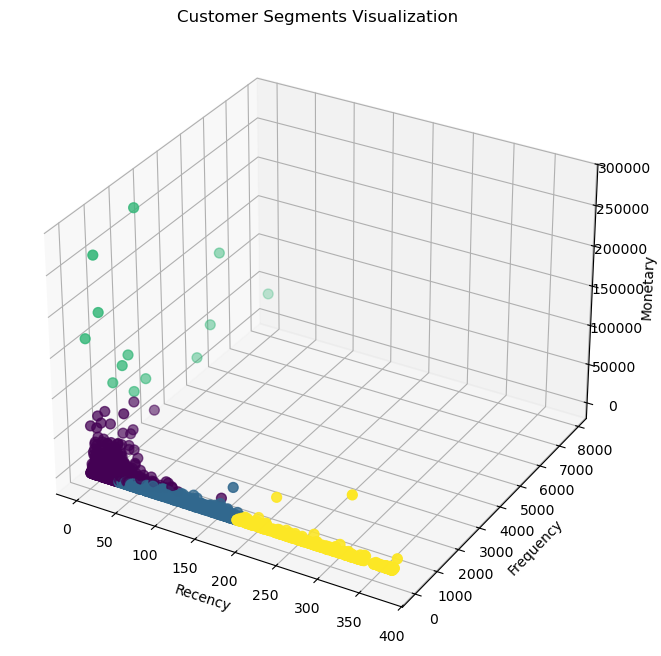

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
           c=rfm['Cluster'], cmap='viridis', s=50)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('Customer Segments Visualization')
plt.show()

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. تجهيز البيانات: الآلة تحتاج أن تكون الأرقام متقاربة في النطاق (Scaling)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 2. بناء الموديل: سنطلب من الحاسوب تقسيمهم إلى 4 مجموعات (Clusters)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 3. عرض متوسط كل مجموعة لفهم الفرق بينهم
print("تحليل خصائص كل مجموعة من العملاء:")
print(rfm.groupby('Cluster').mean())

تحليل خصائص كل مجموعة من العملاء:
            Recency    Frequency       Monetary
Cluster                                        
0         20.990788   135.285122    2645.818172
1         98.218703    37.719457     773.877083
2          4.692308  2565.307692  126118.310000
3        272.407005    25.138889     605.842525


In [26]:
# حساب القيم الثلاث لكل عميل:
# 1. Recency: كم يوم مضى على آخر عملية شراء؟
# 2. Frequency: كم مرة اشترى؟
# 3. Monetary: إجمالي ما أنفقه؟

import datetime as dt

# تحديد تاريخ مرجعي (يوم بعد آخر عملية شراء في البيانات)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# تجميع البيانات حسب كل عميل
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

# إعادة تسمية الأعمدة
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("تم تجهيز جدول RFM لتصنيف العملاء:")
rfm.head()

تم تجهيز جدول RFM لتصنيف العملاء:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [25]:
# تجربة توقع يدوي: لو بعنا 10 قطع بسعر 5 دولار، كم يتوقع الموديل؟
new_data = [[10, 5]] 
prediction = model.predict(new_data)

print(f"توقع النموذج لإجمالي الفاتورة لـ 10 قطع بسعر 5$ هو: {prediction[0]:.2f}")

توقع النموذج لإجمالي الفاتورة لـ 10 قطع بسعر 5$ هو: 19.94


c:\Users\mohan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
# التوقع باستخدام بيانات الاختبار
y_pred = model.predict(X_test)

# حساب مدى دقة التوقع (R-squared)
accuracy = r2_score(y_test, y_pred)
print(f"دقة النموذج هي: {accuracy * 100:.2f}%")

دقة النموذج هي: 52.25%


In [22]:
# إنشاء نسخة من خوارزمية الانحدار الخطي
model = LinearRegression()

# تدريب النموذج باستخدام بيانات التدريب
model.fit(X_train, y_train)

print("انتهت عملية التدريب. الآلة الآن ذكية بما يكفي للتوقع!")

انتهت عملية التدريب. الآلة الآن ذكية بما يكفي للتوقع!


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# اختيار الميزات والهدف
X = df[['Quantity', 'UnitPrice']]
y = df['TotalAmount']

# تقسيم البيانات: 80% للتدريب و 20% للاختبار
# تأكد من كتابة test_size بشكل صحيح هنا
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("تم تقسيم البيانات بنجاح!")

تم تقسيم البيانات بنجاح!


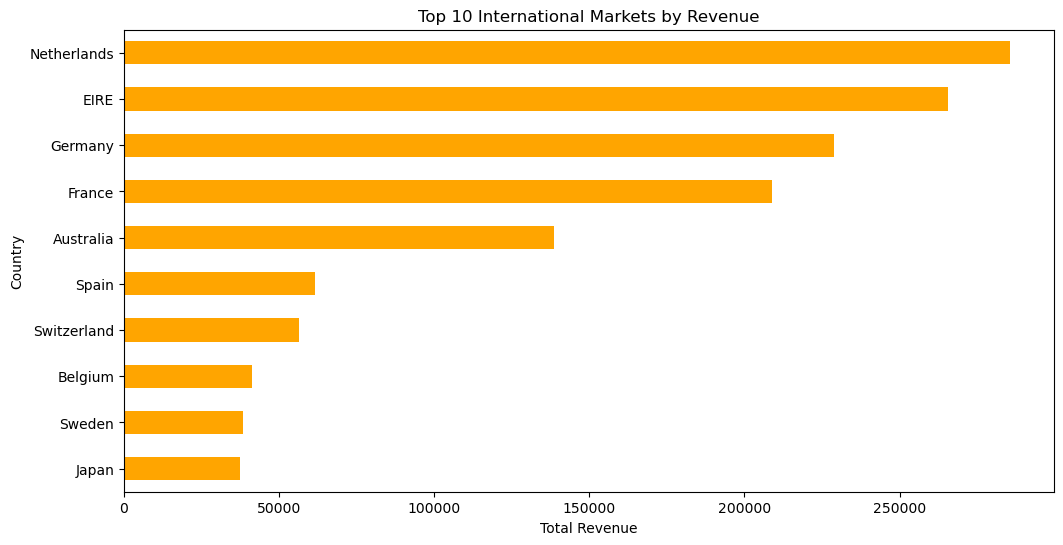

In [11]:
plt.figure(figsize=(12, 6))
international_sales.plot(kind='barh', color='orange')
plt.title('Top 10 International Markets by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.gca().invert_yaxis() # لجعل الدولة الأعلى في المقدمة
plt.show()

In [10]:
# حساب المبيعات لكل دولة واستبعاد المملكة المتحدة لرؤية السوق الدولي بوضوح
international_sales = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

print("أعلى 10 دول شراءً (خارج المملكة المتحدة):")
print(international_sales)

أعلى 10 دول شراءً (خارج المملكة المتحدة):
Country
Netherlands    285446.34
EIRE           265545.90
Germany        228867.14
France         209024.05
Australia      138521.31
Spain           61577.11
Switzerland     56443.95
Belgium         41196.34
Sweden          38378.33
Japan           37416.37
Name: TotalAmount, dtype: float64


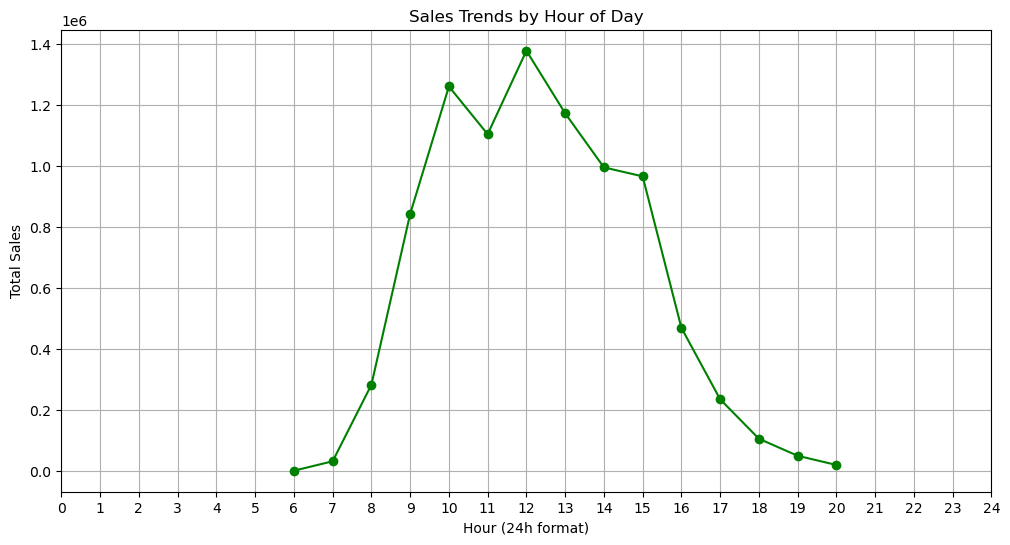

In [9]:
plt.figure(figsize=(12, 6))
sales_by_hour.plot(kind='line', marker='o', color='green')
plt.title('Sales Trends by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(range(0, 25))
plt.show()

In [8]:
# تحويل عمود التاريخ إلى صيغة datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# استخراج الساعة من التاريخ
df['Hour'] = df['InvoiceDate'].dt.hour

# حساب إجمالي المبيعات لكل ساعة
sales_by_hour = df.groupby('Hour')['TotalAmount'].sum()

print("تحليل المبيعات حسب ساعات اليوم:")
print(sales_by_hour)

تحليل المبيعات حسب ساعات اليوم:
Hour
6           4.250
7       31059.210
8      282115.630
9      842605.171
10    1261192.571
11    1104558.750
12    1378571.480
13    1173264.750
14     995629.371
15     966191.750
16     468885.800
17     234413.521
18     104954.430
19      49028.460
20      18932.760
Name: TotalAmount, dtype: float64


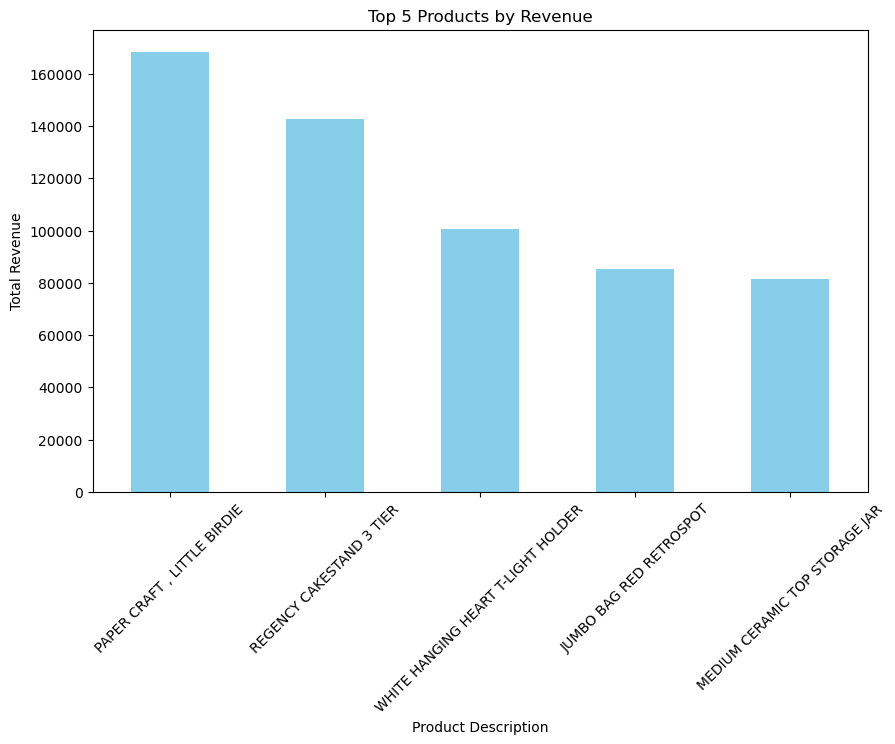

In [7]:
import matplotlib.pyplot as plt

# رسم بياني لأعلى 5 منتجات
top_5_products.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product Description')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [6]:
# إضافة عمود لإجمالي الربح لكل فاتورة
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# معرفة أعلى 5 منتجات مبيعاً
top_5_products = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(5)

print("أغلى 5 منتجات من حيث الإيرادات:")
print(top_5_products)

أغلى 5 منتجات من حيث الإيرادات:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: TotalAmount, dtype: float64


In [5]:
# 1. حذف الصفوف التي تحتوي على قيم مفقودة في رقم العميل
df.dropna(subset=['CustomerID'], inplace=True)

# 2. الاحتفاظ فقط بالعمليات التي تكون كميتها وسعرها أكبر من صفر
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"عدد السجلات بعد التنظيف: {df.shape[0]}")

عدد السجلات بعد التنظيف: 397884


In [4]:
# معرفة عدد القيم المفقودة في كل عمود
print("القيم المفقودة:")
print(df.isnull().sum())

# رؤية وصف إحصائي سريع (هل هناك كميات سالبة؟)
df.describe()

القيم المفقودة:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalPrice          0
dtype: int64


,Quantity,UnitPrice,CustomerID,TotalPrice
count,541909.000000,541909.000000,406829.000000,541909.000000
mean,9.552250,4.611114,15287.690570,17.987795
std,218.081158,96.759853,1713.600303,378.810824
min,-80995.000000,-11062.060000,12346.000000,-168469.600000
25%,1.000000,1.250000,13953.000000,3.400000
50%,3.000000,2.080000,15152.000000,9.750000
75%,10.000000,4.130000,16791.000000,17.400000
max,80995.000000,38970.000000,18287.000000,168469.600000


In [3]:
# حساب إجمالي السعر (الكمية × سعر الوحدة)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# عرض أكثر 5 منتجات مبيعاً من حيث القيمة المالية
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(5)

print("أعلى 5 منتجات مبيعاً (من حيث الإيرادات):")
print(top_products)

أعلى 5 منتجات مبيعاً (من حيث الإيرادات):
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
Name: TotalPrice, dtype: float64


In [2]:
# 1. معرفة عدد الصفوف والأعمدة
print(f"عدد السجلات: {df.shape[0]} صف، وعدد الأعمدة: {df.shape[1]}")

# 2. التحقق من وجود قيم فارغة في كل عمود
print("\nالقيم الفارغة في كل عمود:")
print(df.isnull().sum())

عدد السجلات: 541909 صف، وعدد الأعمدة: 8

القيم الفارغة في كل عمود:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [1]:
import pandas as pd

# قراءة البيانات مع تحديد الترميز لضمان عدم حدوث أخطاء في النصوص
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# عرض أول 5 أسطر لاستكشاف البيانات
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
